In [1]:
'''
VAKA & ÖLÜM VERİLERİ
total_cases	O tarihe kadar toplam kümülatif vaka sayısı
new_cases	O günkü yeni vaka sayısı
new_cases_smoothed	Yeni vakaların 7 günlük hareketli ortalaması 
total_deaths / new_deaths / new_deaths_smoothed	Aynı mantık, ölüm için
*_per_million uzantılı olanlar	Yukarıdakilerin milyon kişi başına normalize edilmiş hali — 
ülkeler arası karşılaştırma için bunları kullanacağız
'''

'\nVAKA & ÖLÜM VERİLERİ\ntotal_cases\tO tarihe kadar toplam kümülatif vaka sayısı\nnew_cases\tO günkü yeni vaka sayısı\nnew_cases_smoothed\tYeni vakaların 7 günlük hareketli ortalaması \ntotal_deaths / new_deaths / new_deaths_smoothed\tAynı mantık, ölüm için\n*_per_million uzantılı olanlar\tYukarıdakilerin milyon kişi başına normalize edilmiş hali — \nülkeler arası karşılaştırma için bunları kullanacağız\n'

In [2]:
#gerekli kütüphanelerin yüklenmesi
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
#temizlenmiş df_countries verisi üzerinde çalışıyoruz.
df_countries = pd.read_csv(
    r'C:\Users\nazlican\OneDrive\Masaüstü\CoronaVirusProject\data\processed\countries_clean.csv',
    parse_dates=['date']
)

In [4]:
print("Satır-sütun sayısı:", df_countries.shape)
print("Ülke sayısı:", df_countries['location'].nunique())
print("İlk tarih:", df_countries['date'].min())
print("Son tarih:", df_countries['date'].max())

Satır-sütun sayısı: (324819, 67)
Ülke sayısı: 194
İlk tarih: 2020-01-01 00:00:00
Son tarih: 2024-08-14 00:00:00


In [5]:
#duplicate değerler kalmadığını kontrol ediyoruz
print(
    "Kalan ülke-tarih tekrarı:",
    df_countries.duplicated(
        subset=['location', 'date']
    ).sum()
)

Kalan ülke-tarih tekrarı: 0


In [6]:
#total_cases nan olanların,ve nan olmayan ülkelerin kaç tane olduğunu ülke bazında incelenmesi
case_coverage = df_countries.groupby('location').agg(
    toplam_satir=('total_cases', 'size'),
    dolu_vaka_kaydi=('total_cases', 'count')
)

case_coverage['bos_vaka_kaydi'] = (
    case_coverage['toplam_satir']
    - case_coverage['dolu_vaka_kaydi']
)

print(
    case_coverage
    .sort_values('dolu_vaka_kaydi')
    .head(15)
)

                     toplam_satir  dolu_vaka_kaydi  bos_vaka_kaydi
location                                                          
Afghanistan                  1674             1674               0
Albania                      1674             1674               0
Algeria                      1674             1674               0
Andorra                      1674             1674               0
Angola                       1674             1674               0
Antigua and Barbuda          1674             1674               0
Argentina                    1678             1674               4
Armenia                      1674             1674               0
Australia                    1674             1674               0
Austria                      1674             1674               0
Azerbaijan                   1674             1674               0
Bahamas                      1674             1674               0
Bahrain                      1674             1674            

In [7]:
#hem dolu hem boş vaka kaydı olan ülkeleri inceliyoruz
partial_missing = case_coverage[
    (case_coverage['dolu_vaka_kaydi'] > 0)
    & (case_coverage['bos_vaka_kaydi'] > 0)
]

print(partial_missing.sort_values('bos_vaka_kaydi', ascending=False))

             toplam_satir  dolu_vaka_kaydi  bos_vaka_kaydi
location                                                  
Malaysia             1684             1674              10
Lithuania            1684             1674              10
India                1682             1674               8
Czechia              1682             1674               8
Estonia              1682             1674               8
New Zealand          1681             1674               7
Argentina            1678             1674               4
Mexico               1678             1674               4
Italy                1677             1674               3
Thailand             1675             1674               1


In [8]:
#Boş kayıtların veri setinde nerede olduğunu inceliyoruz.
missing_case_rows = df_countries.loc[
    df_countries['location'].isin(partial_missing.index)
    & df_countries['total_cases'].isna(),
    ['location', 'date', 'total_cases']
]

# Her konum için eksik kayıtları özetle.
missing_summary = missing_case_rows.groupby('location').agg(
    ilk_bos_tarih=('date', 'min'),
    son_bos_tarih=('date', 'max'),
    bos_kayit_sayisi=('date', 'size')
)

print(missing_summary)

            ilk_bos_tarih son_bos_tarih  bos_kayit_sayisi
location                                                 
Argentina      2020-01-01    2020-01-04                 4
Czechia        2024-08-05    2024-08-12                 8
Estonia        2024-08-05    2024-08-12                 8
India          2024-08-05    2024-08-12                 8
Italy          2024-08-05    2024-08-07                 3
Lithuania      2024-08-05    2024-08-14                10
Malaysia       2024-08-05    2024-08-14                10
Mexico         2020-01-01    2020-01-04                 4
New Zealand    2024-08-05    2024-08-11                 7
Thailand       2020-01-04    2020-01-04                 1


In [9]:
#boş kayıtlar dolu kayıtların arasında mı değil mi kodu
valid_case_range = (
    df_countries.loc[df_countries['total_cases'].notna()]
    .groupby('location')
    .agg(
        ilk_dolu_tarih=('date', 'min'),
        son_dolu_tarih=('date', 'max')
    )
)

coverage_comparison = missing_summary.join(valid_case_range)

print(coverage_comparison)

            ilk_bos_tarih son_bos_tarih  bos_kayit_sayisi ilk_dolu_tarih  \
location                                                                   
Argentina      2020-01-01    2020-01-04                 4     2020-01-05   
Czechia        2024-08-05    2024-08-12                 8     2020-01-05   
Estonia        2024-08-05    2024-08-12                 8     2020-01-05   
India          2024-08-05    2024-08-12                 8     2020-01-05   
Italy          2024-08-05    2024-08-07                 3     2020-01-05   
Lithuania      2024-08-05    2024-08-14                10     2020-01-05   
Malaysia       2024-08-05    2024-08-14                10     2020-01-05   
Mexico         2020-01-01    2020-01-04                 4     2020-01-05   
New Zealand    2024-08-05    2024-08-11                 7     2020-01-05   
Thailand       2020-01-04    2020-01-04                 1     2020-01-05   

            son_dolu_tarih  
location                    
Argentina       2024-08-04  


In [10]:
#new_cases değerinin hangi ülkede ne kadar boş değer var ne kadar dolu değer var inceliyoruz. 
new_case_coverage = df_countries.groupby('location').agg(
    toplam_satir=('new_cases', 'size'),
    dolu_yeni_vaka_kaydi=('new_cases', 'count')
)

new_case_coverage['bos_yeni_vaka_kaydi'] = (
    new_case_coverage['toplam_satir']
    - new_case_coverage['dolu_yeni_vaka_kaydi']
)

print(
    new_case_coverage
    .sort_values('bos_yeni_vaka_kaydi', ascending=False)
    .head(15)
)

                   toplam_satir  dolu_yeni_vaka_kaydi  bos_yeni_vaka_kaydi
location                                                                  
United States              1674                  1232                  442
France                     1674                  1274                  400
Spain                      1674                  1282                  392
Germany                    1674                  1282                  392
Lithuania                  1684                  1674                   10
Malaysia                   1684                  1674                   10
Estonia                    1682                  1674                    8
Czechia                    1682                  1674                    8
India                      1682                  1674                    8
New Zealand                1681                  1674                    7
Argentina                  1678                  1674                    4
Mexico                   

In [11]:
#hem dolu hem boş olan ülkeleri inceliyoruz
partial_new_missing = new_case_coverage[
    (new_case_coverage['dolu_yeni_vaka_kaydi'] > 0)
    & (new_case_coverage['bos_yeni_vaka_kaydi'] > 0)
].copy()


missing_new_case_rows = df_countries.loc[
    df_countries['location'].isin(
        partial_new_missing.index
    )
    & df_countries['new_cases'].isna(),
    ['location', 'date', 'new_cases']
]

new_case_missing_summary = (
    missing_new_case_rows
    .groupby('location')
    .agg(
        ilk_bos_tarih=('date', 'min'),
        son_bos_tarih=('date', 'max'),
        bos_kayit_sayisi=('date', 'size')
    )
    .sort_values('bos_kayit_sayisi', ascending=False)
)

print(new_case_missing_summary.head(15))

              ilk_bos_tarih son_bos_tarih  bos_kayit_sayisi
location                                                   
United States    2023-05-21    2024-08-04               442
France           2023-07-02    2024-08-04               400
Germany          2023-07-10    2024-08-04               392
Spain            2023-07-10    2024-08-04               392
Lithuania        2024-08-05    2024-08-14                10
Malaysia         2024-08-05    2024-08-14                10
India            2024-08-05    2024-08-12                 8
Estonia          2024-08-05    2024-08-12                 8
Czechia          2024-08-05    2024-08-12                 8
New Zealand      2024-08-05    2024-08-11                 7
Argentina        2020-01-01    2020-01-04                 4
Mexico           2020-01-01    2020-01-04                 4
Italy            2024-08-05    2024-08-07                 3
Thailand         2020-01-04    2020-01-26                 2
Fiji             2023-10-15    2023-10-1

In [12]:
#boş değerler arada mı ortada mı sonda mı inceliyoruz
valid_new_case_range = (
    df_countries.loc[df_countries['new_cases'].notna()]
    .groupby('location')
    .agg(
        ilk_dolu_tarih=('date', 'min'),
        son_dolu_tarih=('date', 'max')
    )
)

missing_new_positions = missing_new_case_rows.join(
    valid_new_case_range,
    on='location'
)

missing_new_positions['bosluk_konumu'] = 'arada'

missing_new_positions.loc[
    missing_new_positions['date']
    < missing_new_positions['ilk_dolu_tarih'],
    'bosluk_konumu'
] = 'başta'

missing_new_positions.loc[
    missing_new_positions['date']
    > missing_new_positions['son_dolu_tarih'],
    'bosluk_konumu'
] = 'sonda'

missing_position_summary = (
    missing_new_positions
    .groupby(['location', 'bosluk_konumu'])
    .size()
    .unstack(fill_value=0)
    .reindex(columns=['başta', 'arada', 'sonda'], fill_value=0)
)

print(missing_position_summary)

bosluk_konumu         başta  arada  sonda
location                                 
Argentina                 4      0      0
Belize                    0      1      0
Burundi                   0      1      0
Czechia                   0      0      8
Ecuador                   0      1      0
Equatorial Guinea         0      1      0
Estonia                   0      0      8
Fiji                      0      1      0
France                    0      0    400
Germany                   0      0    392
Guatemala                 0      1      0
India                     0      0      8
Italy                     0      0      3
Liberia                   0      1      0
Lithuania                 0      0     10
Malawi                    0      1      0
Malaysia                  0      0     10
Maldives                  0      1      0
Mauritania                0      1      0
Mexico                    4      0      0
Micronesia (country)      0      1      0
New Zealand               0      0

In [13]:
daily_cases = df_countries[
    ['location', 'date', 'new_cases']
].copy()

#haftanın başlangıcını bulmak için bunu yapıyoruz
daily_cases['hafta_baslangici'] = (
    daily_cases['date']
    - pd.to_timedelta(
        daily_cases['date'].dt.dayofweek,
        unit='D'
    )
)

print(
    daily_cases[
        ['location', 'date', 'hafta_baslangici', 'new_cases']
    ].head(10)
)

      location       date hafta_baslangici  new_cases
0  Afghanistan 2020-01-05       2019-12-30        0.0
1  Afghanistan 2020-01-06       2020-01-06        0.0
2  Afghanistan 2020-01-07       2020-01-06        0.0
3  Afghanistan 2020-01-08       2020-01-06        0.0
4  Afghanistan 2020-01-09       2020-01-06        0.0
5  Afghanistan 2020-01-10       2020-01-06        0.0
6  Afghanistan 2020-01-11       2020-01-06        0.0
7  Afghanistan 2020-01-12       2020-01-06        0.0
8  Afghanistan 2020-01-13       2020-01-13        0.0
9  Afghanistan 2020-01-14       2020-01-13        0.0


In [14]:
weekly_cases = (
    daily_cases
    .groupby(['location', 'hafta_baslangici'])
    .agg(
        mevcut_vaka_toplami=(
            'new_cases',
            lambda values: values.sum(min_count=1)
        ),
        kayitli_gun=('date', 'nunique'),
        dolu_gun=('new_cases', 'count')
    )
    .reset_index()
)

weekly_cases['eksik_gun'] = (
    7 - weekly_cases['dolu_gun']
)

weekly_cases['tam_hafta'] = (
    weekly_cases['dolu_gun'] == 7
)

print(
    weekly_cases.head(10).to_string(
        index=False
    )
)

   location hafta_baslangici  mevcut_vaka_toplami  kayitli_gun  dolu_gun  eksik_gun  tam_hafta
Afghanistan       2019-12-30                  0.0            1         1          6      False
Afghanistan       2020-01-06                  0.0            7         7          0       True
Afghanistan       2020-01-13                  0.0            7         7          0       True
Afghanistan       2020-01-20                  0.0            7         7          0       True
Afghanistan       2020-01-27                  0.0            7         7          0       True
Afghanistan       2020-02-03                  0.0            7         7          0       True
Afghanistan       2020-02-10                  0.0            7         7          0       True
Afghanistan       2020-02-17                  0.0            7         7          0       True
Afghanistan       2020-02-24                  1.0            7         7          0       True
Afghanistan       2020-03-02                  0.0 

In [15]:
#zaman içinde total_cases artması veya azalmasını incelememiz lazım.
#Çünkü total_cases zaman içinde artar veya sabit kalması lazım. 
# Eğer azalırsa bu bir veri hatasıdır. 
# Bu yüzden her ülke için total_cases değerlerinin artıp artmadığını kontrol edeceğiz.

case_changes = df_countries[
    ['location', 'date', 'total_cases']
].sort_values(['location', 'date']).copy()

case_changes['degisim'] = (
    case_changes.groupby('location')['total_cases'].diff()
)

decreases = case_changes[
    case_changes['degisim'] < 0
]

print(decreases.to_string(index=False))

            location       date  total_cases  degisim
              Belize 2022-04-10      57287.0     -2.0
             Burundi 2023-07-16      54216.0   -105.0
             Ecuador 2020-09-13     116451.0  -1594.0
   Equatorial Guinea 2022-03-20      15800.0    -98.0
                Fiji 2023-10-15      69040.0     -7.0
           Guatemala 2020-04-05         50.0    -27.0
             Liberia 2023-08-13       7930.0   -160.0
              Malawi 2022-11-06      88009.0    -88.0
            Maldives 2020-03-29         16.0     -1.0
          Mauritania 2023-02-12      63438.0   -124.0
Micronesia (country) 2024-06-02      26460.0    -87.0
               Palau 2023-06-11       6009.0     -2.0
         Philippines 2023-08-20    4108552.0 -65079.0
               Samoa 2023-06-04      16743.0    -20.0
            Thailand 2020-01-26          5.0     -1.0
            Zimbabwe 2023-07-30     265693.0     -1.0


In [16]:
#Philippines tarihlerindeki toplam vaka sayısını incelemek lazım.
#yukarıdaki çıktıya göre ciddi bir düşüş var
philippines_check = df_countries.loc[
    (df_countries['location'] == 'Philippines')
    & df_countries['date'].between('2023-08-17', '2023-08-23'),
    ['location', 'date', 'total_cases', 'new_cases']
].sort_values('date')

print(philippines_check.to_string(index=False))

   location       date  total_cases  new_cases
Philippines 2023-08-17    4173631.0        0.0
Philippines 2023-08-18    4173631.0        0.0
Philippines 2023-08-19    4173631.0        0.0
Philippines 2023-08-20    4108552.0        NaN
Philippines 2023-08-21    4108552.0        0.0
Philippines 2023-08-22    4108552.0        0.0
Philippines 2023-08-23    4108552.0        0.0


In [17]:
#Azalmaların nedenini öğrenmek için new_cases sütununu da ekleyelim.
decrease_details = decreases.merge(
    df_countries[['location', 'date', 'new_cases']],
    on=['location', 'date'],
    how='left',
    validate='one_to_one'
)

print(decrease_details.to_string(index=False))

# Bulgular:
# Kısmen eksik verisi olan 10 konumda boşluklar,
# ilk dolu kayıttan önce veya son dolu kayıttan sonra bulunuyor.
# 19 kayıtta kümülatif toplamın azaldığı görüldü.
# Bu kayıtların tamamında new_cases boş.
#
# Karar:
# Toplam vaka değerleri korunacak; azalma kayıtları işaretlenecek.
# Azalmaların ülkeye özgü nedenleri henüz doğrulanmadı.
# Eksik günlük vaka değerleri sıfırla doldurulmayacak.

            location       date  total_cases  degisim  new_cases
              Belize 2022-04-10      57287.0     -2.0        NaN
             Burundi 2023-07-16      54216.0   -105.0        NaN
             Ecuador 2020-09-13     116451.0  -1594.0        NaN
   Equatorial Guinea 2022-03-20      15800.0    -98.0        NaN
                Fiji 2023-10-15      69040.0     -7.0        NaN
           Guatemala 2020-04-05         50.0    -27.0        NaN
             Liberia 2023-08-13       7930.0   -160.0        NaN
              Malawi 2022-11-06      88009.0    -88.0        NaN
            Maldives 2020-03-29         16.0     -1.0        NaN
          Mauritania 2023-02-12      63438.0   -124.0        NaN
Micronesia (country) 2024-06-02      26460.0    -87.0        NaN
               Palau 2023-06-11       6009.0     -2.0        NaN
         Philippines 2023-08-20    4108552.0 -65079.0        NaN
               Samoa 2023-06-04      16743.0    -20.0        NaN
            Thailand 2020

In [18]:
new_case_coverage = df_countries.groupby('location').agg(
    toplam_satir=('new_cases', 'size'),
    dolu_yeni_vaka_kaydi=('new_cases', 'count')
)

new_case_coverage['bos_yeni_vaka_kaydi'] = (
    new_case_coverage['toplam_satir']
    - new_case_coverage['dolu_yeni_vaka_kaydi']
)

print(
    new_case_coverage
    .sort_values('bos_yeni_vaka_kaydi', ascending=False)
    .head(15)
)

                   toplam_satir  dolu_yeni_vaka_kaydi  bos_yeni_vaka_kaydi
location                                                                  
United States              1674                  1232                  442
France                     1674                  1274                  400
Spain                      1674                  1282                  392
Germany                    1674                  1282                  392
Lithuania                  1684                  1674                   10
Malaysia                   1684                  1674                   10
Estonia                    1682                  1674                    8
Czechia                    1682                  1674                    8
India                      1682                  1674                    8
New Zealand                1681                  1674                    7
Argentina                  1678                  1674                    4
Mexico                   

In [19]:
#United States için new_cases sütununda boş olan değerlerin hangi tarih aralıklarında olduğunun incelenmesi
usa_missing_dates = df_countries.loc[
    (df_countries['location'] == 'United States')
    & df_countries['new_cases'].isna(),#günlük yeni vaka kayıtlarında boş olan değerleri görür.
    'date'
].sort_values()

print("İlk boş tarih:", usa_missing_dates.min())
print("Son boş tarih:", usa_missing_dates.max())
print("Boş kayıt sayısı:", usa_missing_dates.size)

İlk boş tarih: 2023-05-21 00:00:00
Son boş tarih: 2024-08-04 00:00:00
Boş kayıt sayısı: 442


In [20]:
#Fransa için new_cases sütununda boş olan değerlerin hangi tarih aralıklarında olduğunun incelenmesi
france_missing_dates = df_countries.loc[
    (df_countries['location'] == 'France')
    & df_countries['new_cases'].isna(),#günlük yeni vaka kayıtlarında boş olan değerleri görür.
    'date'
].sort_values()

print("İlk boş tarih:", france_missing_dates.min())
print("Son boş tarih:", france_missing_dates.max())
print("Boş kayıt sayısı:", france_missing_dates.size)

İlk boş tarih: 2023-07-02 00:00:00
Son boş tarih: 2024-08-04 00:00:00
Boş kayıt sayısı: 400


In [21]:
#Germany için new_cases sütununda boş olan değerlerin hangi tarih aralıklarında olduğunun incelenmesi
germany_missing_dates = df_countries.loc[
    (df_countries['location'] == 'Germany')
    & df_countries['new_cases'].isna(),#günlük yeni vaka kayıtlarında boş olan değerleri görür.
    'date'
].sort_values()

print("İlk boş tarih:", germany_missing_dates.min())
print("Son boş tarih:", germany_missing_dates.max())
print("Boş kayıt sayısı:", germany_missing_dates.size)

İlk boş tarih: 2023-07-10 00:00:00
Son boş tarih: 2024-08-04 00:00:00
Boş kayıt sayısı: 392


In [22]:
#Spain için new_cases sütununda boş olan değerlerin hangi tarih aralıklarında olduğunun incelenmesi
spain_missing_dates = df_countries.loc[
    (df_countries['location'] == 'Spain')
    & df_countries['new_cases'].isna(),#günlük yeni vaka kayıtlarında boş olan değerleri görür.
    'date'
].sort_values()

print("İlk boş tarih:", spain_missing_dates.min())
print("Son boş tarih:", spain_missing_dates.max())
print("Boş kayıt sayısı:", spain_missing_dates.size)

İlk boş tarih: 2023-07-10 00:00:00
Son boş tarih: 2024-08-04 00:00:00
Boş kayıt sayısı: 392


In [23]:
#new_cases alanı boş olan değerler ve dolu olan değerler için kısmen eksik verisi olan konumlar
partial_new_missing = new_case_coverage[
    (new_case_coverage['dolu_yeni_vaka_kaydi'] > 0)
    & (new_case_coverage['bos_yeni_vaka_kaydi'] > 0)
]

print(
    partial_new_missing.sort_values(
        'bos_yeni_vaka_kaydi', ascending=False
    ).to_string()
)

                      toplam_satir  dolu_yeni_vaka_kaydi  bos_yeni_vaka_kaydi
location                                                                     
United States                 1674                  1232                  442
France                        1674                  1274                  400
Germany                       1674                  1282                  392
Spain                         1674                  1282                  392
Lithuania                     1684                  1674                   10
Malaysia                      1684                  1674                   10
India                         1682                  1674                    8
Estonia                       1682                  1674                    8
Czechia                       1682                  1674                    8
New Zealand                   1681                  1674                    7
Argentina                     1678                  1674        

In [24]:
#her tarihin  haftalık başlangıç tarihini seçip ona göre analiz yapacağız
daily_cases = df_countries[
    ['location', 'date', 'new_cases']
].copy()

daily_cases['hafta_baslangici'] = (
    daily_cases['date']
    - pd.to_timedelta(daily_cases['date'].dt.dayofweek, unit='D')
)

print(
    daily_cases[
        ['location', 'date', 'hafta_baslangici', 'new_cases']
    ].head(10).to_string(index=False)
)

   location       date hafta_baslangici  new_cases
Afghanistan 2020-01-05       2019-12-30        0.0
Afghanistan 2020-01-06       2020-01-06        0.0
Afghanistan 2020-01-07       2020-01-06        0.0
Afghanistan 2020-01-08       2020-01-06        0.0
Afghanistan 2020-01-09       2020-01-06        0.0
Afghanistan 2020-01-10       2020-01-06        0.0
Afghanistan 2020-01-11       2020-01-06        0.0
Afghanistan 2020-01-12       2020-01-06        0.0
Afghanistan 2020-01-13       2020-01-13        0.0
Afghanistan 2020-01-14       2020-01-13        0.0


In [25]:
weekly_cases = (
    daily_cases
    .groupby(['location', 'hafta_baslangici'])
    .agg(
        mevcut_vaka_toplami=(
            'new_cases', lambda values: values.sum(min_count=1)
        ),
        kayitli_gun=('date', 'nunique'),
        dolu_gun=('new_cases', 'count')
    )
    .reset_index()
)

weekly_cases['eksik_gun'] = 7 - weekly_cases['dolu_gun']

weekly_cases['tam_hafta'] = weekly_cases['dolu_gun'] == 7

print(weekly_cases.head(10).to_string(index=False))

   location hafta_baslangici  mevcut_vaka_toplami  kayitli_gun  dolu_gun  eksik_gun  tam_hafta
Afghanistan       2019-12-30                  0.0            1         1          6      False
Afghanistan       2020-01-06                  0.0            7         7          0       True
Afghanistan       2020-01-13                  0.0            7         7          0       True
Afghanistan       2020-01-20                  0.0            7         7          0       True
Afghanistan       2020-01-27                  0.0            7         7          0       True
Afghanistan       2020-02-03                  0.0            7         7          0       True
Afghanistan       2020-02-10                  0.0            7         7          0       True
Afghanistan       2020-02-17                  0.0            7         7          0       True
Afghanistan       2020-02-24                  1.0            7         7          0       True
Afghanistan       2020-03-02                  0.0 

In [26]:
#mevcut_vaka_toplami sütununda boş olan değerler için haftalık yeni vaka sayısını hesaplayamayız.
weekly_cases['haftalik_yeni_vaka'] = (
    weekly_cases['mevcut_vaka_toplami']
    .where(weekly_cases['tam_hafta'])
)

print(
    weekly_cases[
        ['location', 'hafta_baslangici', 'mevcut_vaka_toplami',
         'dolu_gun', 'haftalik_yeni_vaka']
    ].head(10).to_string(index=False)
)

   location hafta_baslangici  mevcut_vaka_toplami  dolu_gun  haftalik_yeni_vaka
Afghanistan       2019-12-30                  0.0         1                 NaN
Afghanistan       2020-01-06                  0.0         7                 0.0
Afghanistan       2020-01-13                  0.0         7                 0.0
Afghanistan       2020-01-20                  0.0         7                 0.0
Afghanistan       2020-01-27                  0.0         7                 0.0
Afghanistan       2020-02-03                  0.0         7                 0.0
Afghanistan       2020-02-10                  0.0         7                 0.0
Afghanistan       2020-02-17                  0.0         7                 0.0
Afghanistan       2020-02-24                  1.0         7                 1.0
Afghanistan       2020-03-02                  0.0         7                 0.0


In [27]:
#günler atlanmış mı bakacağız
weekly_cases = weekly_cases.sort_values(
    ['location', 'hafta_baslangici']
).copy()

weekly_cases['onceki_haftaya_gun_farki'] = (
    weekly_cases.groupby('location')['hafta_baslangici']
    .diff()
    .dt.days
)

week_gaps = weekly_cases.loc[
    weekly_cases['onceki_haftaya_gun_farki'] > 7,
    ['location', 'hafta_baslangici', 'onceki_haftaya_gun_farki']
]

print(week_gaps.to_string(index=False))

Empty DataFrame
Columns: [location, hafta_baslangici, onceki_haftaya_gun_farki]
Index: []


In [28]:
#Kısa zaman aralıklarında doldurulmayan gün var mı
incomplete_weeks = weekly_cases.loc[
    ~weekly_cases['tam_hafta'],
    ['location', 'hafta_baslangici', 'kayitli_gun', 'dolu_gun']
]

print(incomplete_weeks.head(15).to_string(index=False))

           location hafta_baslangici  kayitli_gun  dolu_gun
        Afghanistan       2019-12-30            1         1
            Albania       2019-12-30            1         1
            Algeria       2019-12-30            1         1
            Andorra       2019-12-30            1         1
             Angola       2019-12-30            1         1
Antigua and Barbuda       2019-12-30            1         1
          Argentina       2019-12-30            5         1
            Armenia       2019-12-30            1         1
          Australia       2019-12-30            1         1
            Austria       2019-12-30            1         1
         Azerbaijan       2019-12-30            1         1
            Bahamas       2019-12-30            1         1
            Bahrain       2019-12-30            1         1
         Bangladesh       2019-12-30            1         1
           Barbados       2019-12-30            1         1


In [29]:
week_summary = pd.Series({
    'Toplam hafta kaydı': len(weekly_cases),
    '7 günü dolu': weekly_cases['dolu_gun'].eq(7).sum(),
    '1–6 günü dolu': weekly_cases['dolu_gun'].between(1, 6).sum(),
    'Hiç dolu günü yok': weekly_cases['dolu_gun'].eq(0).sum()
})

print(week_summary)

Toplam hafta kaydı    46572
7 günü dolu           46116
1–6 günü dolu           212
Hiç dolu günü yok       244
dtype: int64


In [30]:
partial_weeks = weekly_cases.loc[
    weekly_cases['dolu_gun'].between(1, 6)
].copy()

first_week = weekly_cases.groupby('location')[
    'hafta_baslangici'
].min()

last_week = weekly_cases.groupby('location')[
    'hafta_baslangici'
].max()

partial_weeks['sinir_haftasi'] = (
    partial_weeks['hafta_baslangici'].eq(
        partial_weeks['location'].map(first_week)
    )
    | partial_weeks['hafta_baslangici'].eq(
        partial_weeks['location'].map(last_week)
    )
)

print(partial_weeks['sinir_haftasi'].value_counts())

sinir_haftasi
True     194
False     18
Name: count, dtype: int64


In [31]:
interior_partial_weeks = partial_weeks.loc[
    ~partial_weeks['sinir_haftasi'],
    ['location', 'hafta_baslangici', 'kayitli_gun', 'dolu_gun']
].sort_values(['location', 'hafta_baslangici'])

print(interior_partial_weeks.to_string(index=False))

            location hafta_baslangici  kayitli_gun  dolu_gun
              Belize       2022-04-04            7         6
             Burundi       2023-07-10            7         6
             Ecuador       2020-09-07            7         6
   Equatorial Guinea       2022-03-14            7         6
                Fiji       2023-10-09            7         6
              France       2023-06-26            7         6
           Guatemala       2020-03-30            7         6
             Liberia       2023-08-07            7         6
              Malawi       2022-10-31            7         6
            Maldives       2020-03-23            7         6
          Mauritania       2023-02-06            7         6
Micronesia (country)       2024-05-27            7         6
               Palau       2023-06-05            7         6
         Philippines       2023-08-14            7         6
               Samoa       2023-05-29            7         6
            Thailand    

In [32]:
#boş günlerin tarihlerini buluyoruz
interior_missing_days = daily_cases.merge(
    interior_partial_weeks[['location', 'hafta_baslangici']],
    on=['location', 'hafta_baslangici'],
    how='inner',
    validate='many_to_one'
)

interior_missing_days = interior_missing_days.loc[
    interior_missing_days['new_cases'].isna(),
    ['location', 'date', 'new_cases']
]

print(interior_missing_days.to_string(index=False))

            location       date  new_cases
              Belize 2022-04-10        NaN
             Burundi 2023-07-16        NaN
             Ecuador 2020-09-13        NaN
   Equatorial Guinea 2022-03-20        NaN
                Fiji 2023-10-15        NaN
              France 2023-07-02        NaN
           Guatemala 2020-04-05        NaN
             Liberia 2023-08-13        NaN
              Malawi 2022-11-06        NaN
            Maldives 2020-03-29        NaN
          Mauritania 2023-02-12        NaN
Micronesia (country) 2024-06-02        NaN
               Palau 2023-06-11        NaN
         Philippines 2023-08-20        NaN
               Samoa 2023-06-04        NaN
            Thailand 2020-01-26        NaN
       United States 2023-05-21        NaN
            Zimbabwe 2023-07-30        NaN


In [33]:
#hafta bazında değişimi görmek için
weekly_cases = weekly_cases.sort_values(
    ['location', 'hafta_baslangici']
).copy()

weekly_cases['onceki_hafta_vaka'] = (
    weekly_cases.groupby('location')['haftalik_yeni_vaka']
    .shift(1)
)

weekly_cases['haftalik_degisim'] = (
    weekly_cases['haftalik_yeni_vaka']
    - weekly_cases['onceki_hafta_vaka']
)

weekly_cases['haftalik_degisim_yuzde'] = (
    weekly_cases['haftalik_degisim']
    .div(
        weekly_cases['onceki_hafta_vaka'].where(
            weekly_cases['onceki_hafta_vaka'] > 0
        )
    )
    .mul(100)
)

In [34]:
#Türkiye üzerinde değişimi görmek için
print(
    weekly_cases.loc[
        (weekly_cases['location'] == 'Turkey')
        & weekly_cases['hafta_baslangici'].between(
            '2021-01-04', '2021-02-01'
        ),
        ['hafta_baslangici', 'haftalik_yeni_vaka',
         'onceki_hafta_vaka', 'haftalik_degisim',
         'haftalik_degisim_yuzde']
    ].to_string(index=False)
)

hafta_baslangici  haftalik_yeni_vaka  onceki_hafta_vaka  haftalik_degisim  haftalik_degisim_yuzde
      2021-01-04             85083.0            98662.0          -13579.0              -13.763151
      2021-01-11             63547.0            85083.0          -21536.0              -25.311754
      2021-01-18             43663.0            63547.0          -19884.0              -31.290226
      2021-01-25             46573.0            43663.0            2910.0                6.664682
      2021-02-01             53885.0            46573.0            7312.0               15.700084


In [35]:
turkey_weekly = weekly_cases.loc[
    weekly_cases['location'] == 'Turkey',
    ['hafta_baslangici', 'dolu_gun', 'haftalik_yeni_vaka',
     'onceki_hafta_vaka', 'haftalik_degisim',
     'haftalik_degisim_yuzde']
].sort_values('hafta_baslangici')

print(turkey_weekly.to_string(index=False))

hafta_baslangici  dolu_gun  haftalik_yeni_vaka  onceki_hafta_vaka  haftalik_degisim  haftalik_degisim_yuzde
      2019-12-30         1                 NaN                NaN               NaN                     NaN
      2020-01-06         7                 0.0                NaN               NaN                     NaN
      2020-01-13         7                 0.0                0.0               0.0                     NaN
      2020-01-20         7                 0.0                0.0               0.0                     NaN
      2020-01-27         7                 0.0                0.0               0.0                     NaN
      2020-02-03         7                 0.0                0.0               0.0                     NaN
      2020-02-10         7                 0.0                0.0               0.0                     NaN
      2020-02-17         7                 0.0                0.0               0.0                     NaN
      2020-02-24         7  

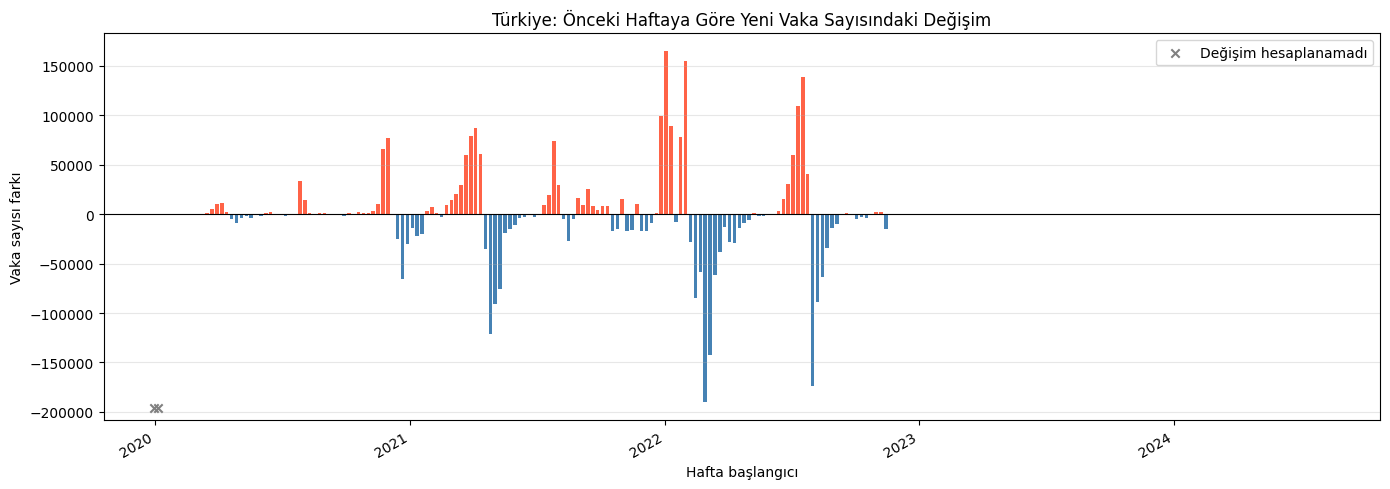

In [36]:
#haftalık toplam vaka değişimi Türkiye çapında
import numpy as np
import matplotlib.pyplot as plt
plot_data = turkey_weekly.sort_values(
    'hafta_baslangici'
).copy()

colors = np.where(
    plot_data['haftalik_degisim'] >= 0,
    'tomato',
    'steelblue'
)

fig, ax = plt.subplots(figsize=(14, 5))

ax.bar(
    plot_data['hafta_baslangici'],
    plot_data['haftalik_degisim'],
    color=colors,
    width=5
)

# Değişim hesaplanamayan haftaları ayrıca işaretle.
missing = plot_data['haftalik_degisim'].isna()

ax.scatter(
    plot_data.loc[missing, 'hafta_baslangici'],
    np.full(missing.sum(), 0.03),
    transform=ax.get_xaxis_transform(),
    marker='x',
    color='gray',
    label='Değişim hesaplanamadı',
    zorder=3
)

ax.axhline(0, color='black', linewidth=0.8)
ax.set_title('Türkiye: Önceki Haftaya Göre Yeni Vaka Sayısındaki Değişim')
ax.set_xlabel('Hafta başlangıcı')
ax.set_ylabel('Vaka sayısı farkı')
ax.grid(axis='y', alpha=0.3)
ax.legend()

fig.autofmt_xdate()
plt.tight_layout()
plt.show()

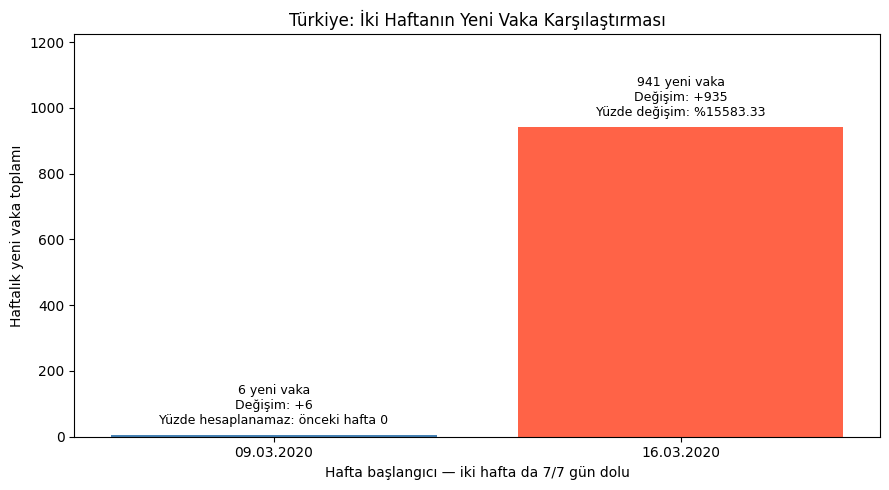

In [37]:
selected_weeks = turkey_weekly.loc[
    turkey_weekly['hafta_baslangici'].between(
        '2020-03-09', '2020-03-16'
    )
].copy()

labels = selected_weeks['hafta_baslangici'].dt.strftime('%d.%m.%Y')

fig, ax = plt.subplots(figsize=(9, 5))

bars = ax.bar(
    labels,
    selected_weeks['haftalik_yeni_vaka'],
    color=['steelblue', 'tomato']
)

for bar, (_, row) in zip(bars, selected_weeks.iterrows()):
    if pd.isna(row['haftalik_degisim_yuzde']):
        percentage_text = 'Yüzde hesaplanamaz: önceki hafta 0'
    else:
        percentage_text = (
            f"Yüzde değişim: %{row['haftalik_degisim_yuzde']:.2f}"
        )

    text = (
        f"{row['haftalik_yeni_vaka']:.0f} yeni vaka\n"
        f"Değişim: {row['haftalik_degisim']:+.0f}\n"
        f"{percentage_text}"
    )

    ax.annotate(
        text,
        (bar.get_x() + bar.get_width() / 2, bar.get_height()),
        xytext=(0, 8),
        textcoords='offset points',
        ha='center',
        fontsize=9
    )

ax.set_title('Türkiye: İki Haftanın Yeni Vaka Karşılaştırması')
ax.set_xlabel('Hafta başlangıcı — iki hafta da 7/7 gün dolu')
ax.set_ylabel('Haftalık yeni vaka toplamı')
ax.margins(y=0.30)

plt.tight_layout()
plt.show()

In [38]:
#türkiye çapında total cases incelenmesi
turkey_total_cases = df_countries.loc[
    df_countries['location'] == 'Turkey',
    ['date', 'total_cases']
].sort_values('date').copy()

print(turkey_total_cases.head())
print(turkey_total_cases.tail())

             date  total_cases
294687 2020-01-05          0.0
294688 2020-01-06          0.0
294689 2020-01-07          0.0
294690 2020-01-08          0.0
294691 2020-01-09          0.0
             date  total_cases
296356 2024-07-31   17004718.0
296357 2024-08-01   17004718.0
296358 2024-08-02   17004718.0
296359 2024-08-03   17004718.0
296360 2024-08-04   17004718.0


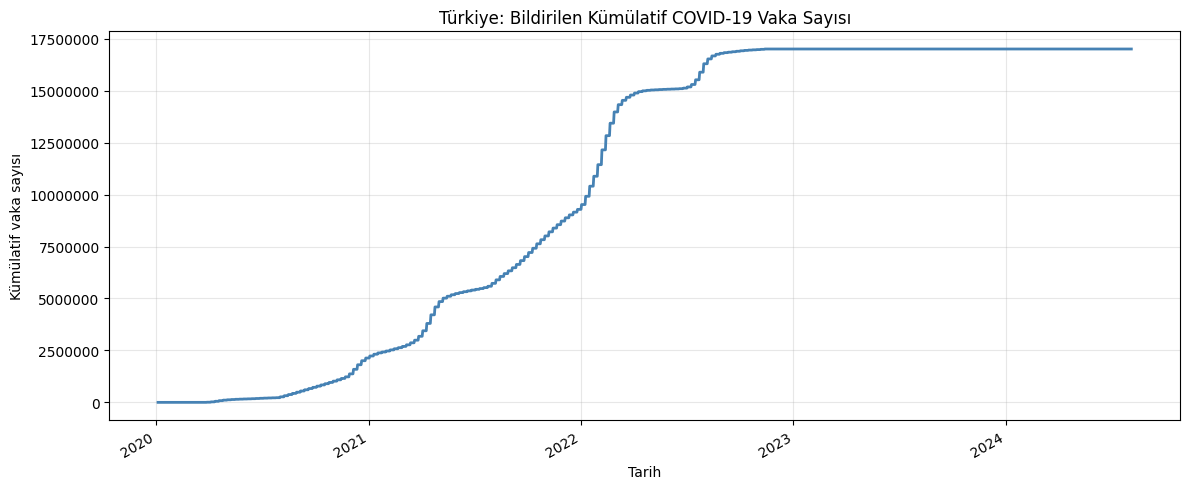

In [39]:
fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(
    turkey_total_cases['date'],
    turkey_total_cases['total_cases'],
    color='steelblue',
    linewidth=2
)

ax.set_title('Türkiye: Bildirilen Kümülatif COVID-19 Vaka Sayısı')
ax.set_xlabel('Tarih')
ax.set_ylabel('Kümülatif vaka sayısı')

ax.ticklabel_format(axis='y', style='plain')
ax.grid(alpha=0.3)

fig.autofmt_xdate()
plt.tight_layout()
plt.show()

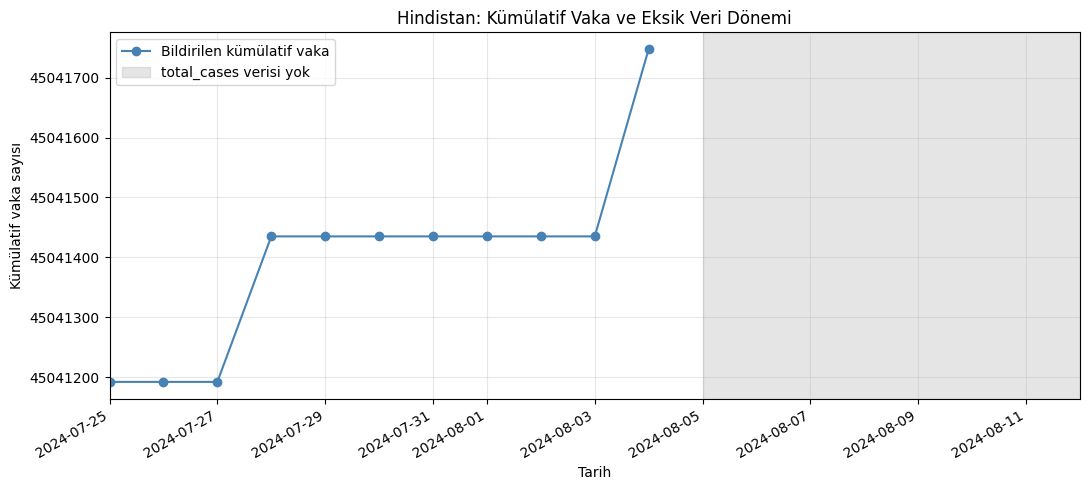

In [40]:
#hindistanda kümülatif toplam nasıl değişmiş bunu inceliyoruz
india_cases = df_countries.loc[
    (df_countries['location'] == 'India')
    & df_countries['date'].between('2024-07-25', '2024-08-12'),
    ['date', 'total_cases']
].sort_values('date').copy()

fig, ax = plt.subplots(figsize=(11, 5))

ax.plot(
    india_cases['date'],
    india_cases['total_cases'],
    marker='o',
    color='steelblue',
    label='Bildirilen kümülatif vaka'
)

ax.axvspan(
    pd.Timestamp('2024-08-05'),
    pd.Timestamp('2024-08-12'),
    color='gray',
    alpha=0.2,
    label='total_cases verisi yok'
)

ax.set_xlim(
    pd.Timestamp('2024-07-25'),
    pd.Timestamp('2024-08-12')
)

ax.set_title('Hindistan: Kümülatif Vaka ve Eksik Veri Dönemi')
ax.set_xlabel('Tarih')
ax.set_ylabel('Kümülatif vaka sayısı')
ax.ticklabel_format(axis='y', style='plain', useOffset=False)
ax.grid(alpha=0.3)
ax.legend()

fig.autofmt_xdate()
plt.tight_layout()
plt.show()

In [41]:
#2021-01-04 tarihlerinde bütün ülkelerin total_cases değerlerinin incelenmesi
selected_week = pd.Timestamp('2021-01-04')

# Bütün konumları koru.
all_locations = df_countries[['location']].drop_duplicates()

# Seçilen haftanın sonuçlarını al.
week_values = weekly_cases.loc[
    weekly_cases['hafta_baslangici'].eq(selected_week),
    ['location', 'haftalik_yeni_vaka', 'mevcut_vaka_toplami',
     'kayitli_gun', 'dolu_gun', 'haftalik_degisim_yuzde']
]

week_comparison = all_locations.merge(
    week_values,
    on='location',
    how='left',
    validate='one_to_one'
)

# Yalnızca kayıt ve dolu gün sayılarını sıfırla tamamla.
count_columns = ['kayitli_gun', 'dolu_gun']

week_comparison[count_columns] = (
    week_comparison[count_columns].fillna(0).astype(int)
)

week_comparison['veri_durumu'] = np.select(
    [
        week_comparison['kayitli_gun'].eq(0),
        week_comparison['dolu_gun'].eq(0),
        week_comparison['dolu_gun'].lt(7)
    ],
    [
        'Bu haftada kayıt yok',
        'Yeni vaka verisi yok',
        'Kısmen dolu hafta'
    ],
    default='7 gün dolu'
)

week_comparison = week_comparison.sort_values(
    'haftalik_yeni_vaka',
    ascending=False,
    na_position='last'
)

print(week_comparison.to_string(index=False))
print('\nVeri durumu özeti:')
print(week_comparison['veri_durumu'].value_counts())

                        location  haftalik_yeni_vaka  mevcut_vaka_toplami  kayitli_gun  dolu_gun  haftalik_degisim_yuzde veri_durumu
                   United States           1667151.0            1667151.0            7         7               20.721002  7 gün dolu
                  United Kingdom            422675.0             422675.0            7         7               11.902266  7 gün dolu
                          Brazil            313130.0             313130.0            7         7               24.249062  7 gün dolu
                          Russia            165167.0             165167.0            7         7              -11.457122  7 gün dolu
                           Spain            160591.0             160591.0            7         7               62.293458  7 gün dolu
                         Germany            145505.0             145505.0            7         7               18.341968  7 gün dolu
                           India            126319.0             1263

C:\Users\nazlican\AppData\Local\Temp\ipykernel_24988\1282852240.py:41: DeprecationWarning: The 'generic' unit for NumPy timedelta is deprecated, and will raise an error in the future. This includes implicit conversion of bare integers (e.g. `+ 1`).Please use a specific unit instead.
  week_end = selected_week + pd.Timedelta(days=6)


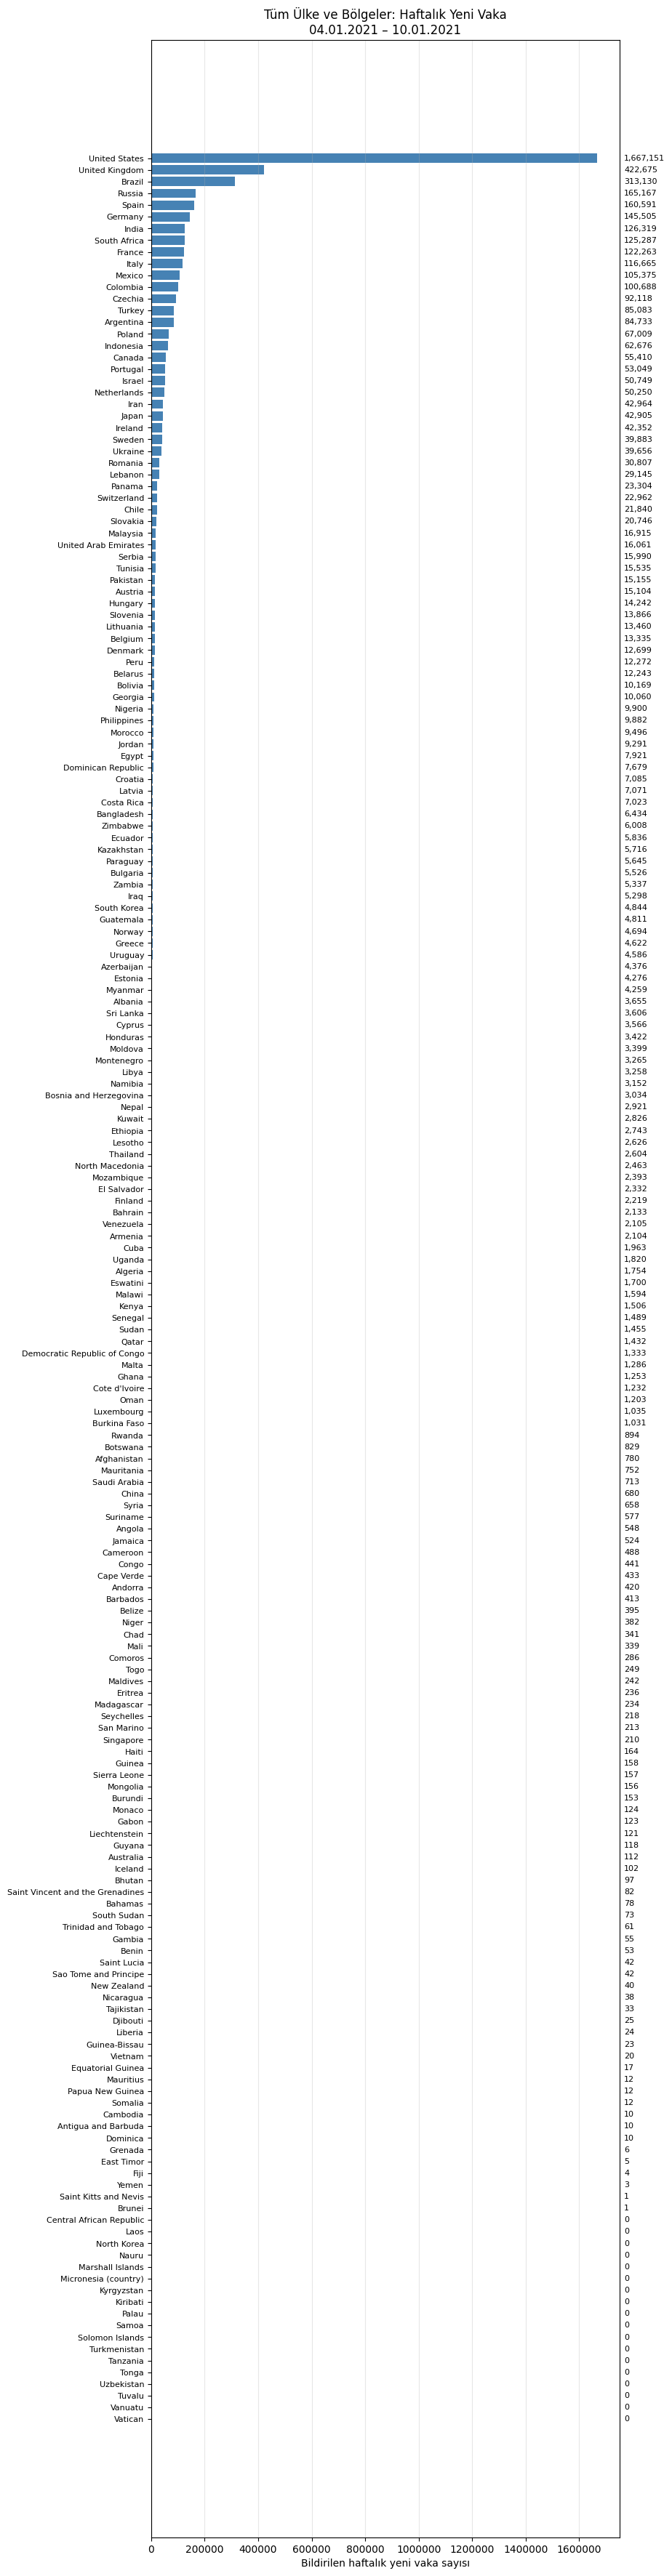

In [42]:
plot_week = week_comparison.sort_values(
    'haftalik_yeni_vaka',
    ascending=False,
    na_position='last'
).reset_index(drop=True)

fig, ax = plt.subplots(
    figsize=(14, max(8, len(plot_week) * 0.23))
)

valid = plot_week['haftalik_yeni_vaka'].notna()

# Yalnızca tam haftalık toplamı bulunan konumların çubuklarını çiz.
ax.barh(
    plot_week.index[valid],
    plot_week.loc[valid, 'haftalik_yeni_vaka'],
    color='steelblue'
)

# Eksik konumları sıfır vaka gibi göstermeden açıklamayla belirt.
for i, row in plot_week.iterrows():
    if pd.isna(row['haftalik_yeni_vaka']):
        label = row['veri_durumu']
        color = 'darkorange'
    else:
        label = f"{row['haftalik_yeni_vaka']:,.0f}"
        color = 'black'

    ax.text(
        1.01, i, label,
        transform=ax.get_yaxis_transform(),
        va='center',
        fontsize=8,
        color=color
    )

ax.set_yticks(plot_week.index)
ax.set_yticklabels(plot_week['location'], fontsize=8)
ax.invert_yaxis()

week_end = selected_week + pd.Timedelta(days=6)

ax.set_title(
    f"Tüm Ülke ve Bölgeler: Haftalık Yeni Vaka\n"
    f"{selected_week:%d.%m.%Y} – {week_end:%d.%m.%Y}"
)
ax.set_xlabel('Bildirilen haftalık yeni vaka sayısı')
ax.ticklabel_format(axis='x', style='plain', useOffset=False)
ax.grid(axis='x', alpha=0.3)

fig.subplots_adjust(left=0.27, right=0.73)
plt.show()

In [43]:
#population sütunun incelenmesi
population_check = df_countries.groupby('location').agg(
    toplam_satir=('population', 'size'),
    dolu_nufus_kaydi=('population', 'count'),
    farkli_nufus_degeri=('population', 'nunique'),
    en_dusuk_nufus=('population', 'min'),
    en_yuksek_nufus=('population', 'max')
)

needs_review = population_check.loc[
    (population_check['dolu_nufus_kaydi']
     < population_check['toplam_satir'])#eksik nüfus bilgisi var mı
    | population_check['farkli_nufus_degeri'].ne(1)#farklı değer sayısı bir değilse işaretle
    | population_check['en_dusuk_nufus'].le(0)#nüfus sıfırdan küçük veya eşit
]

print(needs_review.to_string())

Empty DataFrame
Columns: [toplam_satir, dolu_nufus_kaydi, farkli_nufus_degeri, en_dusuk_nufus, en_yuksek_nufus]
Index: []


In [44]:
population_by_location = (
    df_countries.groupby('location')['population'].first()
)

weekly_cases['population'] = (
    weekly_cases['location'].map(population_by_location)
)

weekly_cases['haftalik_vaka_milyon_basina'] = (
    weekly_cases['haftalik_yeni_vaka']
    / weekly_cases['population']
    * 1_000_000
)

print(
    weekly_cases[
        ['location', 'hafta_baslangici', 'haftalik_yeni_vaka',
         'population', 'haftalik_vaka_milyon_basina']
    ].head(10).to_string(index=False)
)

   location hafta_baslangici  haftalik_yeni_vaka  population  haftalik_vaka_milyon_basina
Afghanistan       2019-12-30                 NaN    41128772                          NaN
Afghanistan       2020-01-06                 0.0    41128772                     0.000000
Afghanistan       2020-01-13                 0.0    41128772                     0.000000
Afghanistan       2020-01-20                 0.0    41128772                     0.000000
Afghanistan       2020-01-27                 0.0    41128772                     0.000000
Afghanistan       2020-02-03                 0.0    41128772                     0.000000
Afghanistan       2020-02-10                 0.0    41128772                     0.000000
Afghanistan       2020-02-17                 0.0    41128772                     0.000000
Afghanistan       2020-02-24                 1.0    41128772                     0.024314
Afghanistan       2020-03-02                 0.0    41128772                     0.000000


In [45]:
#4-10 Ocak 2021 haftasında haftalık toplam vaka sayısının milyon başına analizi 
selected_week = pd.Timestamp('2021-01-04')

week_per_million = weekly_cases.loc[
    (weekly_cases['hafta_baslangici'] == selected_week)
    & weekly_cases['tam_hafta'],
    ['location', 'haftalik_yeni_vaka',
     'population', 'haftalik_vaka_milyon_basina']
].sort_values('haftalik_vaka_milyon_basina', ascending=False)

print(week_per_million.head(15).to_string(index=False))

      location  haftalik_yeni_vaka  population  haftalik_vaka_milyon_basina
       Czechia             92118.0    10493990                  8778.167313
       Ireland             42352.0     5023108                  8431.433288
      Slovenia             13866.0     2119843                  6541.050446
    San Marino               213.0       33690                  6322.350846
United Kingdom            422675.0    67508936                  6261.022985
        Israel             50749.0     9449000                  5370.832892
       Lebanon             29145.0     5489744                  5308.990729
        Panama             23304.0     4408582                  5286.053429
       Andorra               420.0       79843                  5260.323385
    Montenegro              3265.0      627082                  5206.655589
      Portugal             53049.0    10270857                  5165.002297
 United States           1667151.0   338289856                  4928.173194
     Lithuan

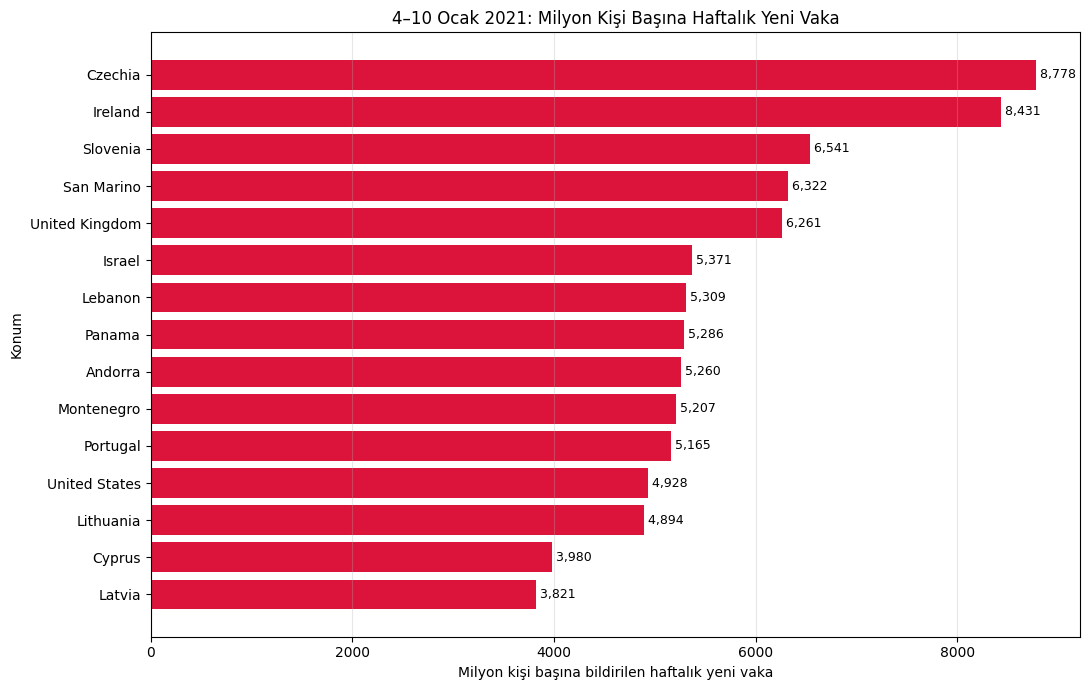

In [46]:
#Çubuk grafikte toplam vakayı incelemek ve milyon kişi başına incelenmesi
plot_per_million = (
    week_per_million
    .head(15)
    .sort_values('haftalik_vaka_milyon_basina')
)

fig, ax = plt.subplots(figsize=(11, 7))

ax.barh(
    plot_per_million['location'],
    plot_per_million['haftalik_vaka_milyon_basina'],
    color='crimson'
)

ax.set_title(
    '4–10 Ocak 2021: Milyon Kişi Başına Haftalık Yeni Vaka'
)
ax.set_xlabel('Milyon kişi başına bildirilen haftalık yeni vaka')
ax.set_ylabel('Konum')
ax.grid(axis='x', alpha=0.3)

for i, value in enumerate(
    plot_per_million['haftalik_vaka_milyon_basina']
):
    ax.text(
        value,
        i,
        f' {value:,.0f}',
        va='center',
        fontsize=9
    )

plt.tight_layout()
plt.show()